[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/egozi/cv22928/blob/main/notebooks/object_detection_voc2007.ipynb)

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

import pandas as pd

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms

import cv2

from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import sys
import os


In [2]:
# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"Running in Google Colab: {IN_COLAB}")

Running in Google Colab: True


In [3]:
repo_path = 'cv22928'

if IN_COLAB:
    # Only clone the repo if the directory doesn't exist
    if not os.path.exists(repo_path):
        print(f"Cloning {repo_path} repository...")
        !git clone https://github.com/egozi/cv22928.git
    else:
        print(f"Repository {repo_path} already exists. Skipping clone.")

    # Append the object_detection module path
    sys.path.append(os.path.join('/content', repo_path, 'object_detection'))
    sys.path.append(os.path.join('/content', repo_path, 'dataset'))

else:
    sys.path.append('../object_detection')  # adjust path as needed
    sys.path.append('../dataset')  # adjust path as needed
    sys.path.append('../tools')  # adjust path as needed
    sys.path.append('../loss')  # adjust path as needed
    sys.path.append('../models')  # adjust path as needed

Repository cv22928 already exists. Skipping clone.


# dataset

In [4]:
from vis import visualize_detection_results, create_detection_summary_plot, plot_yolo_results, draw_im

from voc_datasets import ClassificationDataset

In [5]:

# Download latest version
data_path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

print("Path to dataset files:", data_path)

Path to dataset files: /kaggle/input/pascal-voc-2007


In [6]:
PATH = Path(data_path)
IMAGE_ROOT = PATH / 'voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/'

paths = list(PATH.iterdir())
paths


[PosixPath('/kaggle/input/pascal-voc-2007/VOCtest_06-Nov-2007'),
 PosixPath('/kaggle/input/pascal-voc-2007/voctest_06-nov-2007'),
 PosixPath('/kaggle/input/pascal-voc-2007/VOCtrainval_06-Nov-2007'),
 PosixPath('/kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007'),
 PosixPath('/kaggle/input/pascal-voc-2007/PASCAL_VOC'),
 PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc')]

In [7]:
list((PATH / 'pascal_voc'/ 'PASCAL_VOC').iterdir())

[PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc/PASCAL_VOC/pascal_val2007.json'),
 PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc/PASCAL_VOC/pascal_val2012.json'),
 PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc/PASCAL_VOC/pascal_test2007.json'),
 PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc/PASCAL_VOC/pascal_train2012.json'),
 PosixPath('/kaggle/input/pascal-voc-2007/pascal_voc/PASCAL_VOC/pascal_train2007.json')]

In [8]:
# Load the training annotations
train_json = json.load((PATH/'pascal_voc/PASCAL_VOC/pascal_train2007.json').open())
train_json.keys()

dict_keys(['images', 'type', 'annotations', 'categories'])

In [9]:
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
train_json[IMAGES][:5]

[{'file_name': '000012.jpg', 'height': 333, 'width': 500, 'id': 12},
 {'file_name': '000017.jpg', 'height': 364, 'width': 480, 'id': 17},
 {'file_name': '000023.jpg', 'height': 500, 'width': 334, 'id': 23},
 {'file_name': '000026.jpg', 'height': 333, 'width': 500, 'id': 26},
 {'file_name': '000032.jpg', 'height': 281, 'width': 500, 'id': 32}]

In [10]:
train_json[ANNOTATIONS][:5]

[{'segmentation': [[155, 96, 155, 270, 351, 270, 351, 96]],
  'area': 34104,
  'iscrowd': 0,
  'image_id': 12,
  'bbox': [155, 96, 196, 174],
  'category_id': 7,
  'id': 1,
  'ignore': 0},
 {'segmentation': [[184, 61, 184, 199, 279, 199, 279, 61]],
  'area': 13110,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [184, 61, 95, 138],
  'category_id': 15,
  'id': 2,
  'ignore': 0},
 {'segmentation': [[89, 77, 89, 336, 403, 336, 403, 77]],
  'area': 81326,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [89, 77, 314, 259],
  'category_id': 13,
  'id': 3,
  'ignore': 0},
 {'segmentation': [[8, 229, 8, 500, 245, 500, 245, 229]],
  'area': 64227,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [8, 229, 237, 271],
  'category_id': 2,
  'id': 4,
  'ignore': 0},
 {'segmentation': [[229, 219, 229, 500, 334, 500, 334, 219]],
  'area': 29505,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [229, 219, 105, 281],
  'category_id': 2,
  'id': 5,
  'ignore': 0}]

In [11]:
train_json[CATEGORIES][:5]

[{'supercategory': 'none', 'id': 1, 'name': 'aeroplane'},
 {'supercategory': 'none', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'none', 'id': 3, 'name': 'bird'},
 {'supercategory': 'none', 'id': 4, 'name': 'boat'},
 {'supercategory': 'none', 'id': 5, 'name': 'bottle'}]

In [12]:
# Load the annotation and image info
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
images = {im['id']: im for im in train_json[IMAGES]}
categories = {cat['id']: cat['name'] for cat in train_json[CATEGORIES]}

# Build DataFrame rows
voc_rows = []
for ann in train_json[ANNOTATIONS]:
    image_id = ann['image_id']
    image_info = images[image_id]
    category_id = ann['category_id']
    label_name = categories[category_id]
    # VOC bbox: [x, y, width, height]
    x, y, w, h = ann['bbox']
    row = {
        'ImageID': image_info['file_name'].replace('.jpg', ''),  # match bus-truck style
        'LabelName': label_name,
        'XMin': x / image_info['width'],
        'XMax': (x + w) / image_info['width'],
        'YMin': y / image_info['height'],
        'YMax': (y + h) / image_info['height'],
    }
    voc_rows.append(row)

VOC_DF = pd.DataFrame(voc_rows)
display(VOC_DF.head())

,ImageID,LabelName,XMin,XMax,YMin,YMax
0,000012,car,0.310000,0.702000,0.288288,0.810811
1,000017,person,0.383333,0.581250,0.167582,0.546703
2,000017,horse,0.185417,0.839583,0.211538,0.923077
3,000023,bicycle,0.023952,0.733533,0.458000,1.000000
4,000023,bicycle,0.685629,1.000000,0.438000,1.000000


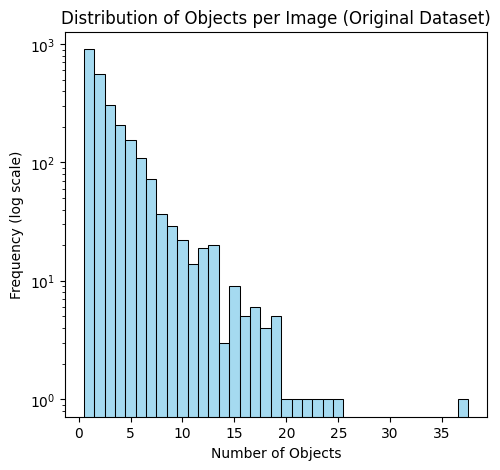

In [13]:
# Count objects per image for the original dataset
original_object_counts = VOC_DF['ImageID'].value_counts()

# Define bins for the original dataset (0-5, 6-10, etc.)
max_original_objects = original_object_counts.max()
original_bins = np.arange(0, max_original_objects + 5, 5)

# Plot histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(original_object_counts, bins=original_bins, kde=False, color='skyblue', discrete=True)
plt.title('Distribution of Objects per Image (Original Dataset)')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')

In [14]:
# create a custom dataset
class OpenImages(Dataset):
    def __init__(self, df, image_folder = IMAGE_ROOT, transforms=None):
        self.df = df
        self.unique_images = df['ImageID'].unique()
        self.root = image_folder
        self.transform = transforms
        self.label2idx = {l: i for i, l in enumerate(sorted(df['LabelName'].unique()))}

    def __len__(self):
        return len(self.unique_images)

    def __getitem__(self, index):
        image_id = self.unique_images[index]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)  # converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # df = self.df
        df = self.df[self.df['ImageID'] == image_id]  # getting the rows based on the index
        h, w, _ = image.shape
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes*np.array([w,h,w,h])).astype(np.uint16)

        classes = df['LabelName'].values.tolist()
        labels = [self.label2idx[cls] for cls in classes]

        # Albumentations format
        if self.transform:
            transformed = self.transform(image=image, bboxes=boxes, class_labels=labels)
            image = transformed['image']
            boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
            labels = torch.tensor(transformed['class_labels'], dtype=torch.long)

        return image, boxes, labels


In [15]:
ds = OpenImages(VOC_DF)

In [16]:
im, bbs, clss = ds[1]
print(im.shape, bbs, clss)


(364, 480, 3) [[184  60 279 198]
 [ 89  77 403 336]] [14, 12]


In [22]:
# Assuming 'ds' is your OpenImages dataset instance
class_names = [label for label, i in ds.label2idx.items()]
print(class_names)

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


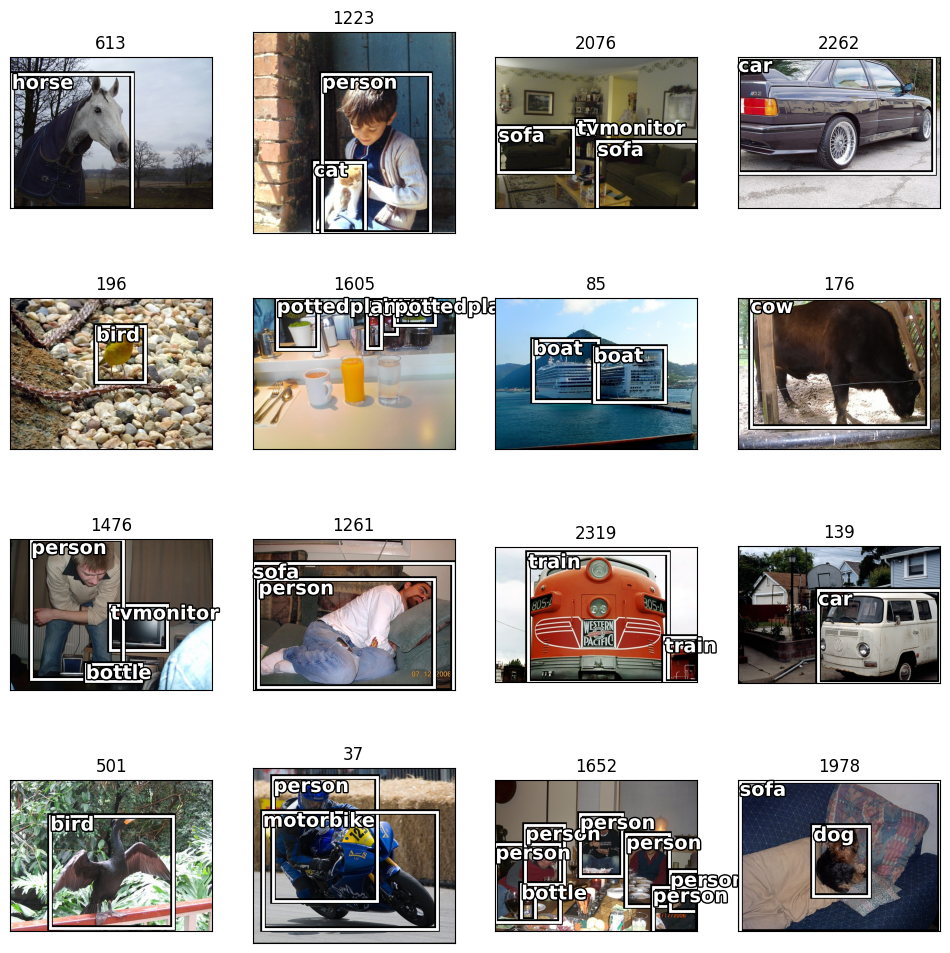

In [25]:
# Randomly select 16 indices
random_indices = np.random.choice(len(ds), 16, replace=False)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the random indices and display the images
for i, idx in enumerate(random_indices):
    im, bbs, clss = ds[idx]
    draw_im(im, bbs=bbs, classes=[class_names[c] for c in clss], ax=axes[i], figsize=(3,3), title=idx)

# only the largest object

In [26]:
# For each image, keep only the largest bounding box and add a column for relative object size
def get_largest_object_df(df, images_dict):
    rows = []
    for image_id, group in df.groupby('ImageID'):
        # Find the largest bbox by area (in pixels)
        max_area = -1
        max_row = None
        for idx, row in group.iterrows():
            img_info = images_dict.get(row['ImageID'] + '.jpg') or images_dict.get(row['ImageID'])
            if img_info is None:
                continue
            w_img, h_img = img_info['width'], img_info['height']
            xmin, xmax = row['XMin'], row['XMax']
            ymin, ymax = row['YMin'], row['YMax']
            # Convert normalized to pixel coordinates
            x1, x2 = xmin * w_img, xmax * w_img
            y1, y2 = ymin * h_img, ymax * h_img
            area = (x2 - x1) * (y2 - y1)
            if area > max_area:
                max_area = area
                max_row = row.copy()
                max_row['object_pixel_area'] = area
                max_row['image_pixel_area'] = w_img * h_img
                max_row['relative_object_size'] = area / (w_img * h_img)
        if max_row is not None:
            rows.append(max_row)
    largest_obj_df = pd.DataFrame(rows)
    return largest_obj_df

largest_object_df = get_largest_object_df(VOC_DF, {im['file_name']: im for im in train_json['images']})
display(largest_object_df.head())

larges_bb_ds = OpenImages(largest_object_df)
print(len(larges_bb_ds))

,ImageID,LabelName,XMin,XMax,YMin,YMax,object_pixel_area,image_pixel_area,relative_object_size
0,000012,car,0.310000,0.702000,0.288288,0.810811,34104.0,166500,0.204829
2,000017,horse,0.185417,0.839583,0.211538,0.923077,81326.0,174720,0.465465
7,000023,person,0.005988,0.727545,0.002000,0.924000,111101.0,167000,0.665275
9,000026,car,0.178000,0.674000,0.372372,0.636637,21824.0,166500,0.131075
10,000032,aeroplane,0.206000,0.750000,0.274021,0.651246,28832.0,140500,0.205210


2501


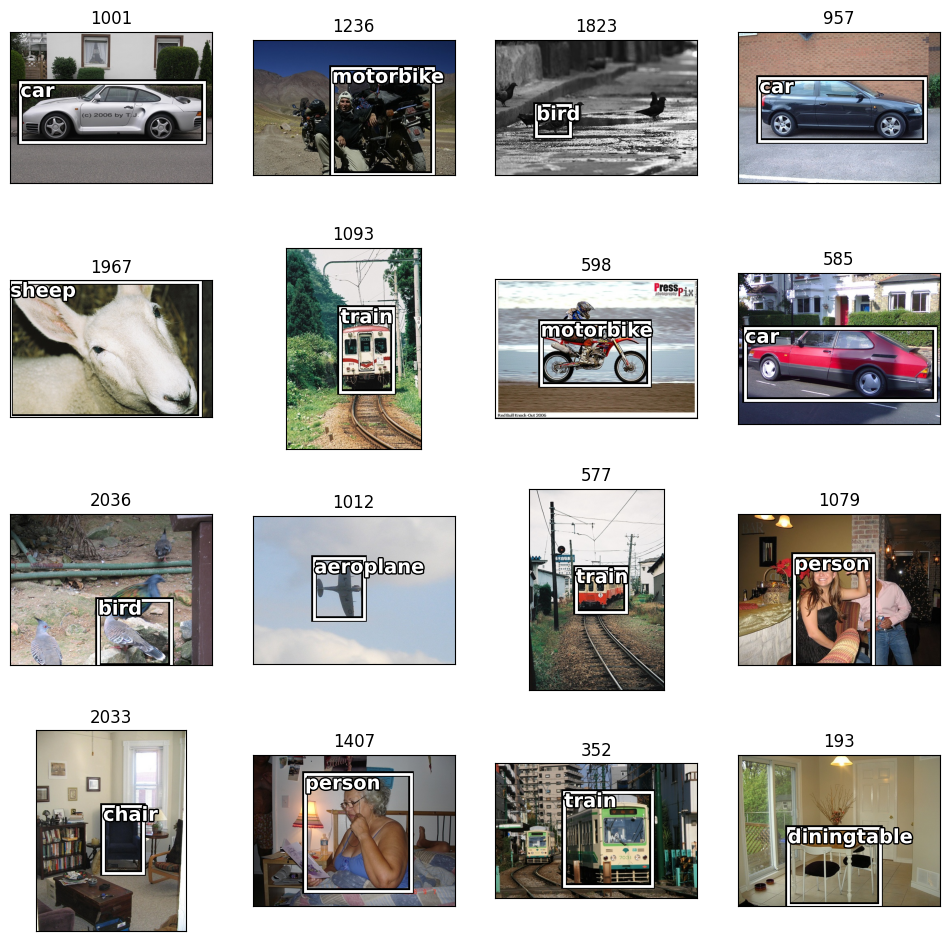

In [30]:
# Randomly select 16 indices
random_indices = np.random.choice(len(larges_bb_ds), 16, replace=False)

# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through the random indices and display the images
for i, idx in enumerate(random_indices):
    im, bbs, clss = larges_bb_ds[idx]
    draw_im(im, bbs=bbs, classes=[class_names[c] for c in clss], ax=axes[i], figsize=(3,3), title=idx)

# train a classifier for biggest object label

In [39]:
# Example transforms for ResNet using Albumentations
def get_classification_transforms():
    return A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

# # Example transforms for ResNet using torchvision.transforms
# def get_classification_transforms_torchvision():
#     return transforms.Compose([
#         transforms.ToPILImage(),
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     ])


transform = get_classification_transforms()

# dataset = ClassificationDataset(largest_object_df, IMAGE_ROOT, transform=transform)
dataset = OpenImages(largest_object_df, IMAGE_ROOT, transforms=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

batch = next(iter(dataloader))
images, boxes, labels = batch
print(images.shape, boxes.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 1, 4]) torch.Size([32, 1])


In [46]:
# Split the dataset into train and validation
train_df, val_df = train_test_split(largest_object_df, test_size=0.2, stratify=largest_object_df['LabelName'], random_state=42)

# Prepare datasets and dataloaders
# train_dataset = ClassificationDataset(train_df, IMAGE_ROOT, transform=transform)
# val_dataset = ClassificationDataset(val_df, IMAGE_ROOT, transform=transform)

train_dataset = OpenImages(train_df, IMAGE_ROOT, transforms=transform)
val_dataset = OpenImages(val_df, IMAGE_ROOT, transforms=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(largest_object_df['LabelName'].unique())
model = models.resnet34(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

epochs = 10
for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, _, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = images.to(device)
        labels = labels.to(device).squeeze(1) # Remove the extra dimension
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, _, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = images.to(device)
            labels = labels.to(device).squeeze(1) # Remove the extra dimension
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

# Save the model
torch.save(model.state_dict(), "resnet34_largest_object.pth")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNe

Epoch 1/10 - Train Loss: 2.5153 - Train Acc: 0.2970 | Val Loss: 1.9721 - Val Acc: 0.4970


Epoch 2 [Val]: 100%|██████████| 16/16 [00:02<00:00,  7.62it/s]


Epoch 2/10 - Train Loss: 1.6422 - Train Acc: 0.6355 | Val Loss: 1.4765 - Val Acc: 0.6547


Epoch 3 [Val]: 100%|██████████| 16/16 [00:02<00:00,  7.39it/s]


...

Epoch 8/10 - Train Loss: 0.3350 - Train Acc: 0.9640 | Val Loss: 0.7728 - Val Acc: 0.7924


Epoch 9 [Val]: 100%|██████████| 16/16 [00:02<00:00,  7.42it/s]


Epoch 9/10 - Train Loss: 0.2605 - Train Acc: 0.9790 | Val Loss: 0.7496 - Val Acc: 0.8004


Epoch 10 [Val]: 100%|██████████| 16/16 [00:02<00:00,  7.49it/s]


Epoch 10/10 - Train Loss: 0.2076 - Train Acc: 0.9885 | Val Loss: 0.7286 - Val Acc: 0.7964


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


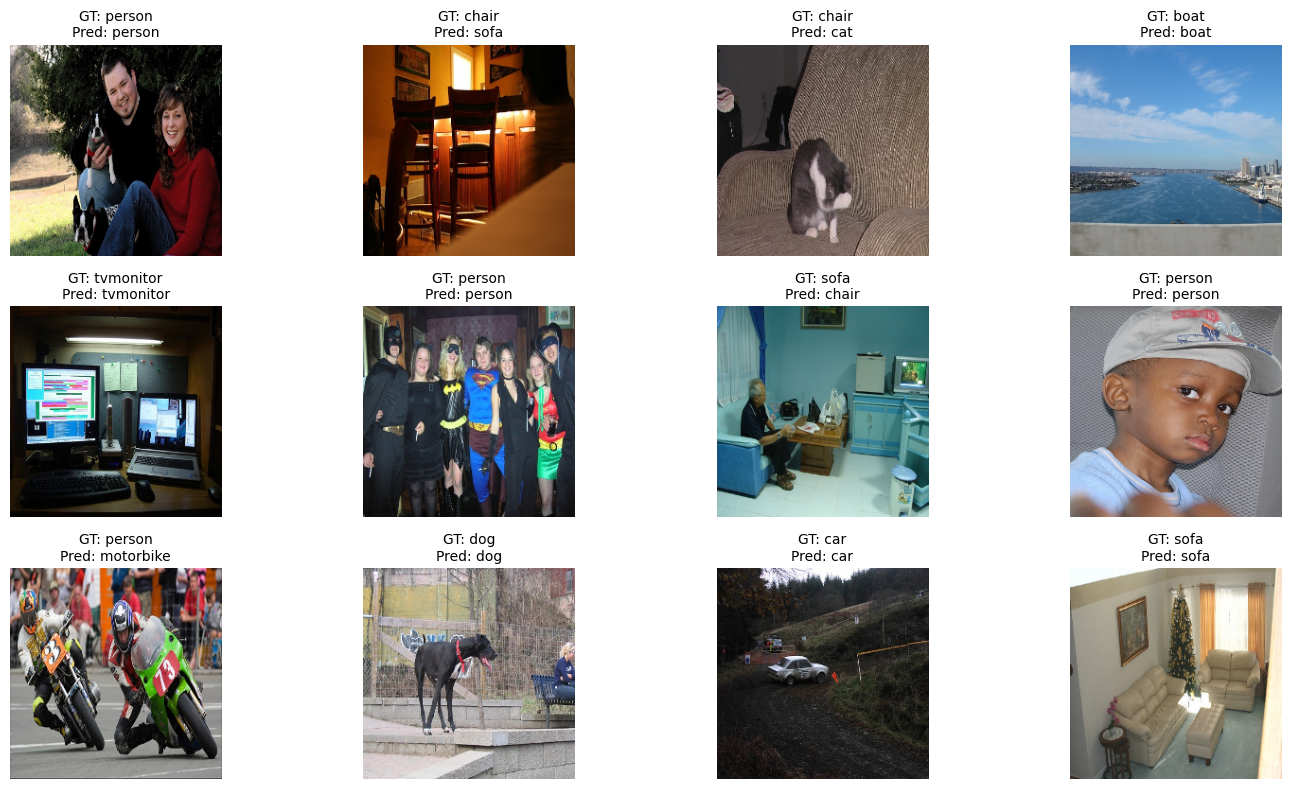

In [49]:
import matplotlib.pyplot as plt

# Set model to eval mode and move to device
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get a batch from the validation set
images, _, labels = next(iter(val_loader))
images = images.to(device)
labels = labels.to(device)
with torch.no_grad():
    outputs = model(images)
    _, preds = outputs.max(1)

# Map indices to label names
idx2label = {i: l for i, l in enumerate(sorted(largest_object_df['LabelName'].unique()))}
true_labels = [idx2label[int(l)] for l in labels.cpu()]
pred_labels = [idx2label[int(p)] for p in preds.cpu()]

# Plot a grid of images with true and predicted labels
n_show = min(12, images.size(0))
plt.figure(figsize=(15, 8))
for i in range(n_show):
    plt.subplot(3, 4, i+1)
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # unnormalize
    img = img.clip(0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"GT: {true_labels[i]}\nPred: {pred_labels[i]}", fontsize=10)

plt.tight_layout()


# classify bounding box only

In [32]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, df, image_dir, classes, transforms=None):
        self.df = df
        self.image_dir = image_dir
        self.transforms = transforms
        self.classes = classes
        self.image_ids = df['ImageID'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df['ImageID'] == image_id]

        # Read image
        image_path = f"{self.image_dir}/{image_id}.jpg"
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width, _ = image.shape

        # Get bboxes and labels
        boxes = []
        labels = []
        for _, row in records.iterrows():
            xmin = row['XMin'] * width
            xmax = row['XMax'] * width
            ymin = row['YMin'] * height
            ymax = row['YMax'] * height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.classes.index(row['LabelName']))

        # Albumentations format
        transformed = self.transforms(image=image, bboxes=boxes, class_labels=labels)
        # transformed = self.transforms(image=image, bboxes=boxes, class_labels=labels)
        image = transformed['image']
        boxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
        labels = torch.tensor(transformed['class_labels'], dtype=torch.long)

        return image, boxes, labels


In [33]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Affine(
            translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},  # shift_limit=0.05
            scale=(0.9, 1.1),  # scale_limit=0.1 means ±10%, so 0.9 to 1.1
            rotate=(-15, 15),  # rotate_limit=15
            p=0.5
        ),
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

def get_val_transforms():
    return A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

In [43]:
ds = ObjectDetectionDataset(largest_object_df, IMAGE_ROOT, classes=class_names, transforms=get_train_transforms())
im, bb, y = ds[0]
print(im.shape, bb.shape, y)

torch.Size([3, 512, 512]) torch.Size([1, 4]) tensor([6])


In [34]:
def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images)
    return images, list(boxes), list(labels)

In [35]:
class_names = sorted(largest_object_df['LabelName'].unique().tolist())

# Split the dataset
train_df, val_df = train_test_split(largest_object_df, test_size=0.2, random_state=42)

train_dataset = ObjectDetectionDataset(train_df, IMAGE_ROOT, classes=class_names, transforms=get_train_transforms())
val_dataset = ObjectDetectionDataset(val_df, IMAGE_ROOT, classes=class_names, transforms=get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, collate_fn=collate_fn)


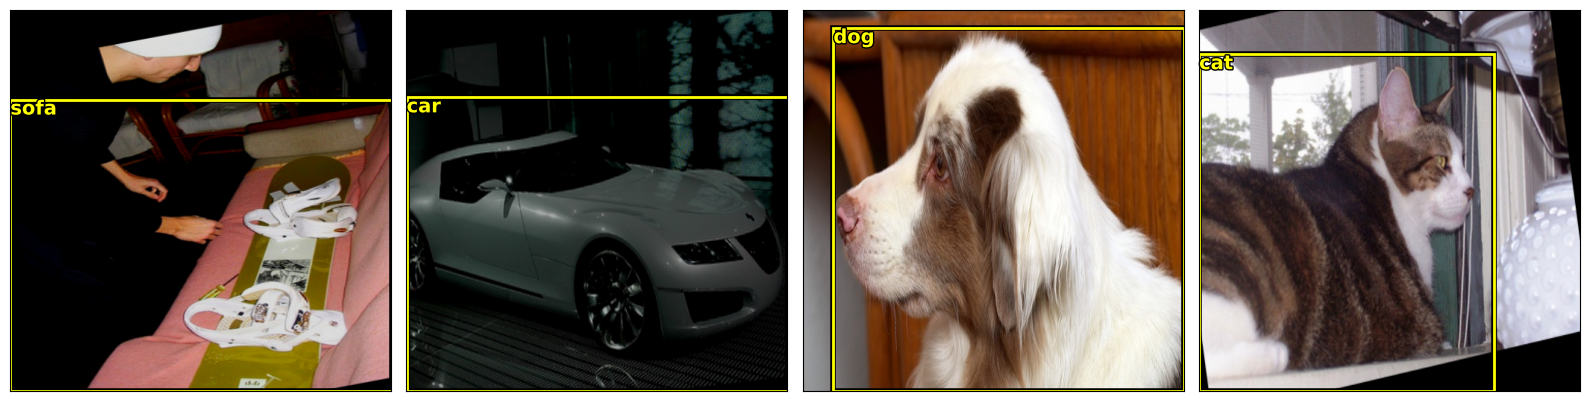

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import torchvision.transforms.functional as F


def denormalize(image, mean, std):
    image = image.clone().permute(1, 2, 0)  # [C,H,W] → [H,W,C]
    image = image * torch.tensor(std) + torch.tensor(mean)
    return image.clamp(0, 1)

mean = [0.485, 0.456, 0.406]  # change if you use different stats
std = [0.229, 0.224, 0.225]

def show_batch(images, boxes, labels, n=4, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        img = denormalize(images[i], mean, std).numpy()

        # Handle the actual data structure
        img_boxes = boxes[i].cpu().numpy() if len(boxes[i]) > 0 else np.array([]).reshape(0, 4)
        img_labels = labels[i].cpu().numpy() if len(labels[i]) > 0 else np.array([])

        # Convert label indices to class names
        cls = [class_names[int(c)] for c in img_labels] if len(img_labels) > 0 else []

        draw_im(img, img_boxes, cls, ax=ax, color='yellow')
    plt.tight_layout()
    plt.show()

# Get a batch from the train_loader
images, boxes, labels = next(iter(train_loader))  # shapes: images [B,3,H,W], boxes [B,4], labels [B]

# Show the batch
show_batch(images, boxes, labels, n=min(4, len(images)))



In [37]:
# Model: ResNet34 with regression head
class ResNet34BBox(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet34(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 4)  # 4 for [XMin, YMin, XMax, YMax]

    def forward(self, x):
        return self.backbone(x)

# Loss flag: 'l1' or 'l2'
loss_type = 'l1'  # Change to 'l2' for MSELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet34BBox(pretrained=True).to(device)
criterion = nn.L1Loss() if loss_type == 'l1' else nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Training and validation loop
epochs = 10
for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    for images, bboxes, _ in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = images.to(device)
        # bboxes = bboxes.to(device)

        # Convert list of tensors to a single tensor (take first bbox from each image)
        bboxes_tensor = torch.stack([bbox[0] if len(bbox) > 0 else torch.zeros(4) for bbox in bboxes])
        bboxes_tensor = bboxes_tensor.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, bboxes_tensor)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes, _ in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            images = images.to(device)

            # Convert list of tensors to a single tensor (take first bbox from each image)
            bboxes_tensor = torch.stack([bbox[0] if len(bbox) > 0 else torch.zeros(4) for bbox in bboxes])
            bboxes_tensor = bboxes_tensor.to(device)
            # bboxes = bboxes.to(device)

            outputs = model(images)
            loss = criterion(outputs, bboxes_tensor)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

# Save the model
torch.save(model.state_dict(), "resnet34_bbox_regression.pth")

Epoch 1 [Val]: 100%|██████████| 32/32 [00:06<00:00,  5.10it/s]


Epoch 1/10 - Train Loss: 104.32513 | Val Loss: 76.44397


Epoch 2 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.44it/s]


Epoch 2/10 - Train Loss: 76.34808 | Val Loss: 76.36889


Epoch 3 [Val]: 100%|██████████| 32/32 [00:06<00:00,  4.58it/s]


...

Epoch 4/10 - Train Loss: 76.09094 | Val Loss: 78.28705


Epoch 5 [Val]: 100%|██████████| 32/32 [00:07<00:00,  4.43it/s]


Epoch 5/10 - Train Loss: 75.81463 | Val Loss: 75.16135


Epoch 6 [Train]:  95%|█████████▌| 119/125 [00:50<00:02,  2.34it/s]


KeyboardInterrupt: 

<Figure size 1600x800 with 0 Axes>

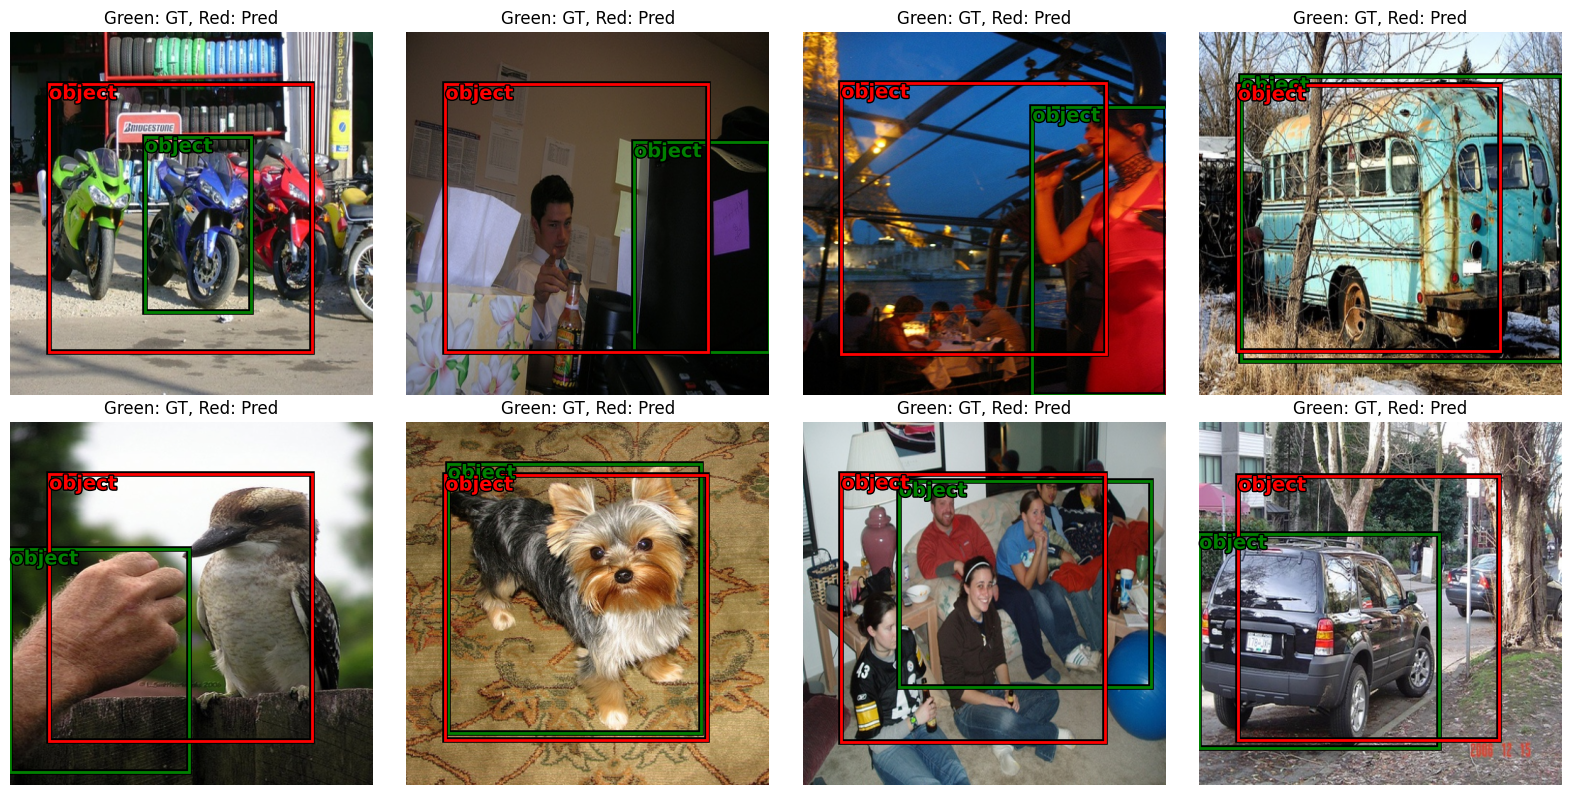

In [ ]:
# Demonstrate bounding box regression results on validation set

import matplotlib.pyplot as plt

model.eval()
images, bboxes, _ = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    preds = model(images).cpu().numpy()
images = images.cpu().permute(0, 2, 3, 1).numpy()
# bboxes = [bb.cpu().numpy() for bb in bboxes] #bboxes.cpu().numpy()

n_show = min(8, images.shape[0])
plt.figure(figsize=(16, 8))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
ax = axes.flatten()
for i in range(n_show):
    plt.subplot(2, 4, i+1)
    img = images[i]
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # unnormalize
    img = img.clip(0, 1)
    h, w = img.shape[:2]
    # True bbox (green)
    # x1, y1, x2, y2 = bboxes[i]
    img_boxes = bboxes[i][0].cpu().numpy() # Get the first bbox from the list for this image
    draw_im(img, [img_boxes], ['gt'], ax=ax[i], color='green')

    draw_im(img, [preds[i]], ['pred'], ax=ax[i], color='red')

    plt.axis('off')
    plt.title("Green: GT, Red: Pred")

plt.tight_layout()

# bounding box and classification

In [ ]:
class ObjectDetectionModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = models.resnet34(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()  # Remove final layer

        # Two separate heads
        self.bbox_head = nn.Linear(in_features, 4)  # x1, y1, x2, y2
        self.class_head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        bbox_pred = self.bbox_head(features)
        class_pred = self.class_head(features)
        return bbox_pred, class_pred


In [ ]:
class ObjectDetectionLoss(nn.Module):
    def __init__(self, bbox_weight=1.0, class_weight=1.0, bbox_loss_type='l1'):
        super().__init__()
        self.bbox_weight = bbox_weight
        self.class_weight = class_weight
        self.bbox_loss = nn.L1Loss() if bbox_loss_type == 'l1' else nn.MSELoss()
        self.class_loss = nn.CrossEntropyLoss()

    def forward(self, bbox_pred, class_pred, bbox_target, class_target):
        bbox_loss = self.bbox_loss(bbox_pred, bbox_target)
        class_loss = self.class_loss(class_pred, class_target)
        total_loss = self.bbox_weight * bbox_loss + self.class_weight * class_loss
        return total_loss, bbox_loss, class_loss


In [ ]:
# Combined Model for Bounding Box Regression and Classification
class ResNet34MultiTask(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = models.resnet34(pretrained=pretrained)

        # Get the number of features from the last layer
        in_features = self.backbone.fc.in_features

        # Remove the original fc layer
        self.backbone.fc = nn.Identity()

        # Add two separate heads
        self.bbox_head = nn.Linear(in_features, 4)  # 4 coordinates: [xmin, ymin, xmax, ymax]
        self.class_head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        bbox = self.bbox_head(features)
        classes = self.class_head(features)
        return bbox, classes

In [ ]:
# Combined Dataset for both tasks
# check later of the original dataset is OK
class ObjectDetectionDataset(Dataset):
    def __init__(self, df, image_dir, classes, transforms=None):
        self.df = df
        self.image_dir = image_dir
        self.transforms = transforms
        self.classes = classes
        self.image_ids = df['ImageID'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        records = self.df[self.df['ImageID'] == image_id]

        # Read image
        image_path = f"{self.image_dir}/{image_id}.jpg"
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width, _ = image.shape

        # Get first (largest) bbox and label
        row = records.iloc[0]
        xmin = row['XMin'] * width
        xmax = row['XMax'] * width
        ymin = row['YMin'] * height
        ymax = row['YMax'] * height
        bbox = [xmin, ymin, xmax, ymax]
        label = self.classes.index(row['LabelName'])

        # Apply transformations
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=[bbox], class_labels=[label])
            image = transformed['image']
            bbox = transformed['bboxes'][0] if len(transformed['bboxes']) > 0 else [0, 0, 1, 1]
            label = transformed['class_labels'][0] if len(transformed['class_labels']) > 0 else 0

        return image, torch.tensor(bbox, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    images, bboxes, labels = zip(*batch)
    images = torch.stack(images)
    bboxes = torch.stack(bboxes)
    labels = torch.stack(labels)
    return images, bboxes, labels



In [ ]:
# Training Configuration
# TODO - check the output of the model to set the loss weights such that they are balanced and have similar magnitudes
config = {
    'num_epochs': 20,
    'batch_size': 16,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'bbox_loss_weight': 1.0,
    'class_loss_weight': 1.0,
    'patience': 5,  # for early stopping
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

# Prepare data
class_names = sorted(largest_object_df['LabelName'].unique().tolist())
num_classes = len(class_names)

# Split dataset
train_df, val_df = train_test_split(
    largest_object_df,
    test_size=0.2,
    stratify=largest_object_df['LabelName'],
    random_state=42
)

# Create datasets
train_dataset = ObjectDetectionDataset(
    train_df, IMAGE_ROOT,
    classes=class_names,
    transforms=get_train_transforms()
)
val_dataset = ObjectDetectionDataset(
    val_df, IMAGE_ROOT,
    classes=class_names,
    transforms=get_val_transforms()
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)



In [ ]:
# Initialize model
model = ResNet34MultiTask(num_classes=num_classes, pretrained=True)
model = model.to(config['device'])

# Loss functions
bbox_criterion = nn.SmoothL1Loss()  # More robust than L1/L2 for bbox regression
class_criterion = nn.CrossEntropyLoss()

# Optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/amir/miniconda3/envs/cv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Training history
history = {
    'train_loss': [], 'train_bbox_loss': [], 'train_class_loss': [], 'train_acc': [],
    'val_loss': [], 'val_bbox_loss': [], 'val_class_loss': [], 'val_acc': []
}

# Early stopping
best_val_loss = float('inf')
patience_counter = 0

# Training Loop
print("Starting training...")
for epoch in range(config['num_epochs']):
    # Training phase
    model.train()
    train_loss = 0.0
    train_bbox_loss = 0.0
    train_class_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']} [Train]")
    for images, bboxes, labels in train_bar:
        images = images.to(config['device'])
        bboxes = bboxes.to(config['device'])
        labels = labels.to(config['device'])

        # Forward pass
        optimizer.zero_grad()
        bbox_pred, class_pred = model(images)

        # Calculate losses
        bbox_loss = bbox_criterion(bbox_pred, bboxes)
        class_loss = class_criterion(class_pred, labels)

        # Combined loss with weights
        total_loss = (config['bbox_loss_weight'] * bbox_loss +
                     config['class_loss_weight'] * class_loss)

        # Backward pass
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        # Statistics
        train_loss += total_loss.item() * images.size(0)
        train_bbox_loss += bbox_loss.item() * images.size(0)
        train_class_loss += class_loss.item() * images.size(0)

        _, predicted = class_pred.max(1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

        # Update progress bar
        train_bar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'bbox': f'{bbox_loss.item():.4f}',
            'class': f'{class_loss.item():.4f}'
        })

    # Calculate training metrics
    train_loss /= len(train_loader.dataset)
    train_bbox_loss /= len(train_loader.dataset)
    train_class_loss /= len(train_loader.dataset)
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_bbox_loss = 0.0
    val_class_loss = 0.0
    val_correct = 0
    val_total = 0

    # Calculate IoU for validation
    val_ious = []

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']} [Val]")
        for images, bboxes, labels in val_bar:
            images = images.to(config['device'])
            bboxes = bboxes.to(config['device'])
            labels = labels.to(config['device'])

            # Forward pass
            bbox_pred, class_pred = model(images)

            # Calculate losses
            bbox_loss = bbox_criterion(bbox_pred, bboxes)
            class_loss = class_criterion(class_pred, labels)
            total_loss = (config['bbox_loss_weight'] * bbox_loss +
                         config['class_loss_weight'] * class_loss)

            # Statistics
            val_loss += total_loss.item() * images.size(0)
            val_bbox_loss += bbox_loss.item() * images.size(0)
            val_class_loss += class_loss.item() * images.size(0)

            _, predicted = class_pred.max(1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

            # Calculate IoU for each prediction
            for i in range(bbox_pred.size(0)):
                pred_box = bbox_pred[i].cpu().numpy()
                true_box = bboxes[i].cpu().numpy()

                # Calculate IoU
                x1 = max(pred_box[0], true_box[0])
                y1 = max(pred_box[1], true_box[1])
                x2 = min(pred_box[2], true_box[2])
                y2 = min(pred_box[3], true_box[3])

                intersection = max(0, x2 - x1) * max(0, y2 - y1)
                pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
                true_area = (true_box[2] - true_box[0]) * (true_box[3] - true_box[1])
                union = pred_area + true_area - intersection

                iou = intersection / (union + 1e-6)
                val_ious.append(iou)

            val_bar.set_postfix({
                'loss': f'{total_loss.item():.4f}',
                'bbox': f'{bbox_loss.item():.4f}',
                'class': f'{class_loss.item():.4f}'
            })

    # Calculate validation metrics
    val_loss /= len(val_loader.dataset)
    val_bbox_loss /= len(val_loader.dataset)
    val_class_loss /= len(val_loader.dataset)
    val_acc = val_correct / val_total
    mean_iou = np.mean(val_ious)

    # Update learning rate
    scheduler.step(val_loss)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_bbox_loss'].append(train_bbox_loss)
    history['train_class_loss'].append(train_class_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_bbox_loss'].append(val_bbox_loss)
    history['val_class_loss'].append(val_class_loss)
    history['val_acc'].append(val_acc)

    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
    print(f"Train - Loss: {train_loss:.4f}, BBox: {train_bbox_loss:.4f}, Class: {train_class_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, BBox: {val_bbox_loss:.4f}, Class: {val_class_loss:.4f}, Acc: {val_acc:.4f}, IoU: {mean_iou:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'mean_iou': mean_iou,
            'class_names': class_names
        }, 'best_multitask_model.pth')
        print(f"✓ Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= config['patience']:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

Starting training...


Epoch 1/20 [Val]: 100%|██████████| 32/32 [01:18<00:00,  2.46s/it, loss=297.5803, bbox=296.9902, class=0.5901]



Epoch 1/20
Train - Loss: 269.7808, BBox: 268.3201, Class: 1.4607, Acc: 0.5880
Val   - Loss: 264.8284, BBox: 263.8615, Class: 0.9669, Acc: 0.7285, IoU: 0.0000
LR: 0.000100
✓ Saved best model (val_loss: 264.8284)


Epoch 2/20 [Val]: 100%|██████████| 32/32 [01:14<00:00,  2.34s/it, loss=291.6546, bbox=290.7433, class=0.9113]



Epoch 2/20
Train - Loss: 262.0236, BBox: 260.9416, Class: 1.0820, Acc: 0.7005
Val   - Loss: 258.8521, BBox: 257.7876, Class: 1.0645, Acc: 0.7126, IoU: 0.0000
LR: 0.000100
✓ Saved best model (val_loss: 258.8521)


...


Epoch 18/20
Train - Loss: 149.4947, BBox: 148.0403, Class: 1.4544, Acc: 0.6155
Val   - Loss: 144.2311, BBox: 142.7056, Class: 1.5255, Acc: 0.5768, IoU: 0.0602
LR: 0.000100
✓ Saved best model (val_loss: 144.2311)


Epoch 19/20 [Val]: 100%|██████████| 32/32 [01:14<00:00,  2.32s/it, loss=154.3991, bbox=153.5921, class=0.8070]



Epoch 19/20
Train - Loss: 142.3923, BBox: 140.9417, Class: 1.4506, Acc: 0.6085
Val   - Loss: 147.0638, BBox: 145.6555, Class: 1.4083, Acc: 0.6507, IoU: 0.0576
LR: 0.000100


Epoch 20/20 [Val]: 100%|██████████| 32/32 [01:14<00:00,  2.32s/it, loss=156.5703, bbox=155.2997, class=1.2706]



Epoch 20/20
Train - Loss: 135.1861, BBox: 133.7388, Class: 1.4473, Acc: 0.6090
Val   - Loss: 142.8629, BBox: 141.2867, Class: 1.5762, Acc: 0.5509, IoU: 0.0699
LR: 0.000100
✓ Saved best model (val_loss: 142.8629)


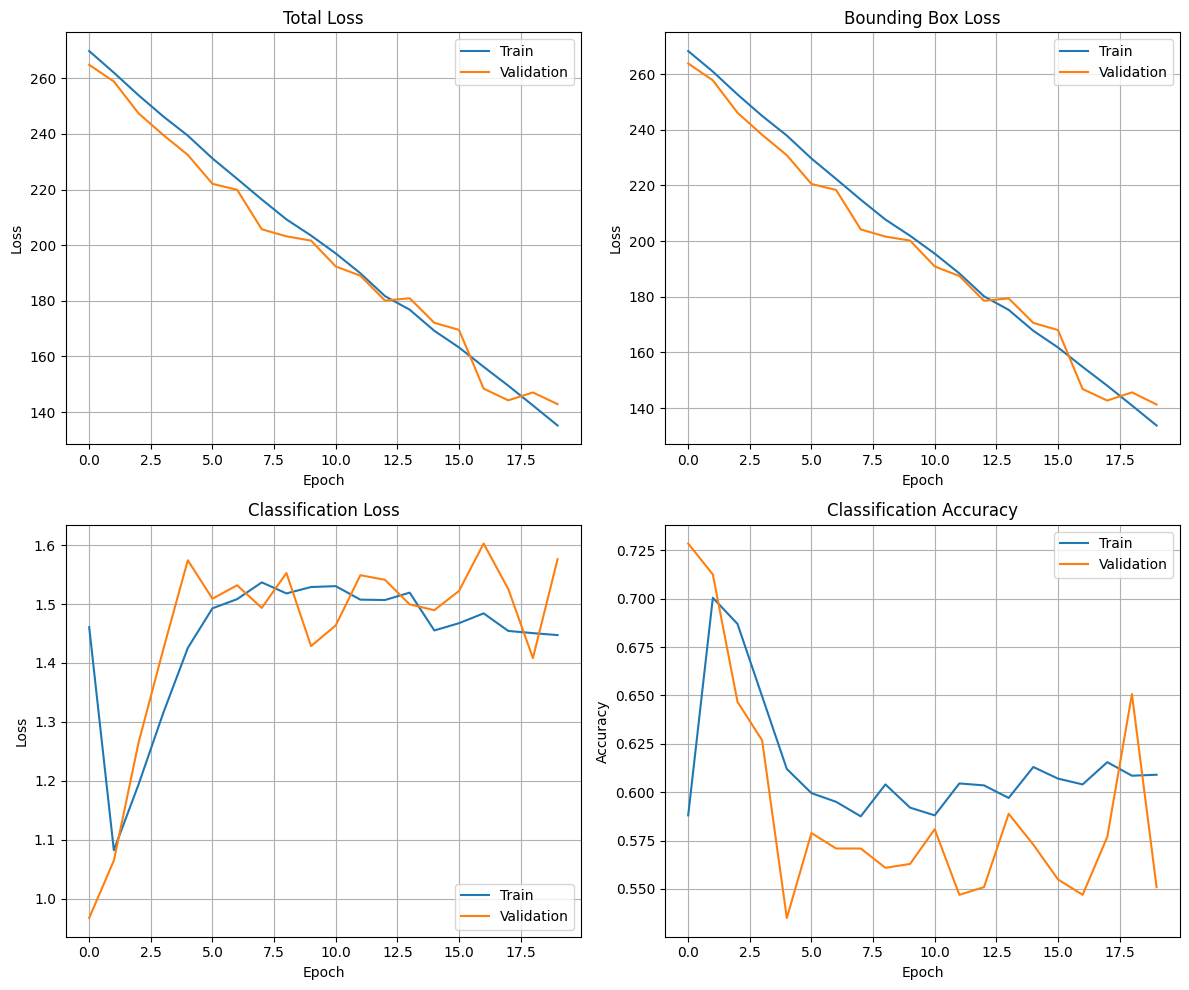


Training completed!
Best validation loss: 142.8629


In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Total loss
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Validation')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# BBox loss
axes[0, 1].plot(history['train_bbox_loss'], label='Train')
axes[0, 1].plot(history['val_bbox_loss'], label='Validation')
axes[0, 1].set_title('Bounding Box Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Classification loss
axes[1, 0].plot(history['train_class_loss'], label='Train')
axes[1, 0].plot(history['val_class_loss'], label='Validation')
axes[1, 0].set_title('Classification Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train')
axes[1, 1].plot(history['val_acc'], label='Validation')
axes[1, 1].set_title('Classification Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
